# Notebook 03 — NLP MapReduce

Analyse des descriptions textuelles par MapReduce PySpark.
Extraction du top 50 mots les plus frequents pour features ML.

In [73]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName('03_nlp_immobilier') \
    .master('local[*]') \
    .config('spark.ui.enabled', 'false') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('SparkSession pret:', spark.version)

SparkSession pret: 4.1.1


## Etape 1 — Chargement du Parquet nettoye

In [74]:
df = spark.read.parquet('../data/clean')
print(f'Lignes chargees : {df.count()}')
df.select('ville', 'description').show(5, truncate=60)

Lignes chargees : 5336
+------+------------------------------------------------------------+
| ville|                                                 description|
+------+------------------------------------------------------------+
|Nantes|Appartement à vendre 1 pièces NANTES (44).\n\nSitué en pl...|
|Nantes|NANTES, Beaujoire, T1 au 5ème et dernier étage.\n\nNANTES...|
|Nantes|Résidence Affaires.\n\nRéalisez un investissement locatif...|
|Nantes|Appartement de 31,49m2 avec balcon et parking sécurisé - ...|
|Nantes|À VENDRE : Appartement T1 à Nantes libre de toute locatio...|
+------+------------------------------------------------------------+
only showing top 5 rows


## Etape 2 — Tokenisation des descriptions

In [75]:
# Tokenisation : split sur espaces et ponctuation
df_desc = df.select('description').filter(F.length('description') > 0)
df_words = df_desc.select(
    F.explode(F.split(F.lower(F.col('description')), r'[^a-zà-ÿéèêëàâäùûüôöîïç]+')).alias('mot')
)
df_words = df_words.filter(F.length('mot') > 2)
print(f'Nombre total de tokens : {df_words.count()}')

Nombre total de tokens : 538516


## Etape 3 — Suppression des stopwords francais

In [76]:
stopwords_fr = [
    'les','des','une','est','que','qui','pour','dans','sur','par',
    'avec','tout','plus','mais','son','ses','ces','vous','nous','ils',
    'elle','ont','pas','bien','tres','aussi','cette','comme','peut',
    'leur','dont','donc','voir','avoir','etre','faire','tous','meme',
    'alors','donc','car','sous','tres','apres','avant','lors','sans',
    'entre','vers','chez','celui','celle','ceux','votre','notre',
    'mon','ton','son','lui','beau','belle','bon','bonne','peu',
    'trop','haut','bas','grand','petit','grande','petite','cet','sont','ainsi',
    'france','honoraires','charges','agence','lots','compose','ème','deux','bordeaux',
    'nantes','très','aux','cours','disponibles','vente','marseille','lyon','pied','sol',
    'ouverte','informations','vendeur','site','classe','charge','propose','offre','offrant',
    'agent', 'annonce','paris','auxquels','quel','situé'
]

df_filtered = df_words.filter(~F.col('mot').isin(stopwords_fr))
df_filtered = df_filtered.filter(F.col('mot').rlike('^[a-zà-ÿéèêëàâäùûüôöîïç]{3,}$'))
print(f'Tokens apres suppression stopwords : {df_filtered.count()}')

Tokens apres suppression stopwords : 375877


## Etape 4 — MapReduce : (mot, 1) -> reduceByKey -> (mot, total)

In [77]:
# MapReduce via groupBy + count (equivalent reduceByKey)
# Map : chaque mot -> (mot, 1)
# Reduce : sum par mot
df_counts = df_filtered.groupBy('mot').count().orderBy(F.desc('count'))
print('MapReduce termine. Top 10 mots :')
df_counts.show(10)

MapReduce termine. Top 10 mots :


+-----------+-----+
|        mot|count|
+-----------+-----+
|appartement| 7548|
|      salle| 4057|
|      étage| 3776|
|    cuisine| 3754|
|        vie| 3382|
|copropriété| 2808|
|   chambres| 2616|
|        eau| 2424|
|     espace| 2412|
|     séjour| 2379|
+-----------+-----+
only showing top 10 rows


## Etape 5 — Extraction du top 50 mots

In [78]:
top50_df = df_counts.limit(50)
top50_pd = top50_df.toPandas()
print('Top 50 mots extraits :', len(top50_pd))
print(top50_pd)

Top 50 mots extraits : 50
            mot  count
0   appartement   7548
1         salle   4057
2         étage   3776
3       cuisine   3754
4           vie   3382
5   copropriété   2808
6      chambres   2616
7           eau   2424
8        espace   2412
9        séjour   2379
10       entrée   2263
11        calme   2207
12     quartier   2170
13    proximité   2088
14       maison   2084
15     immeuble   2045
16       pièces   2005
17   immobilier   1942
18        pièce   1927
19    résidence   1920
20      chambre   1840
21     lumineux   1822
22    commerces   1803
23     terrasse   1765
24          rue   1703
25    ascenseur   1699
26      équipée   1530
27       exposé   1523
28        place   1485
29       jardin   1452
30       balcon   1422
31          vue   1357
32   transports   1297
33         cave   1278
34          sud   1230
35  entièrement   1199
36        idéal   1179
37     agréable   1161
38      parking   1083
39      risques   1064
40        coeur   1064
41      

## Etape 6 — Visualisation : barplot des 20 mots les plus frequents

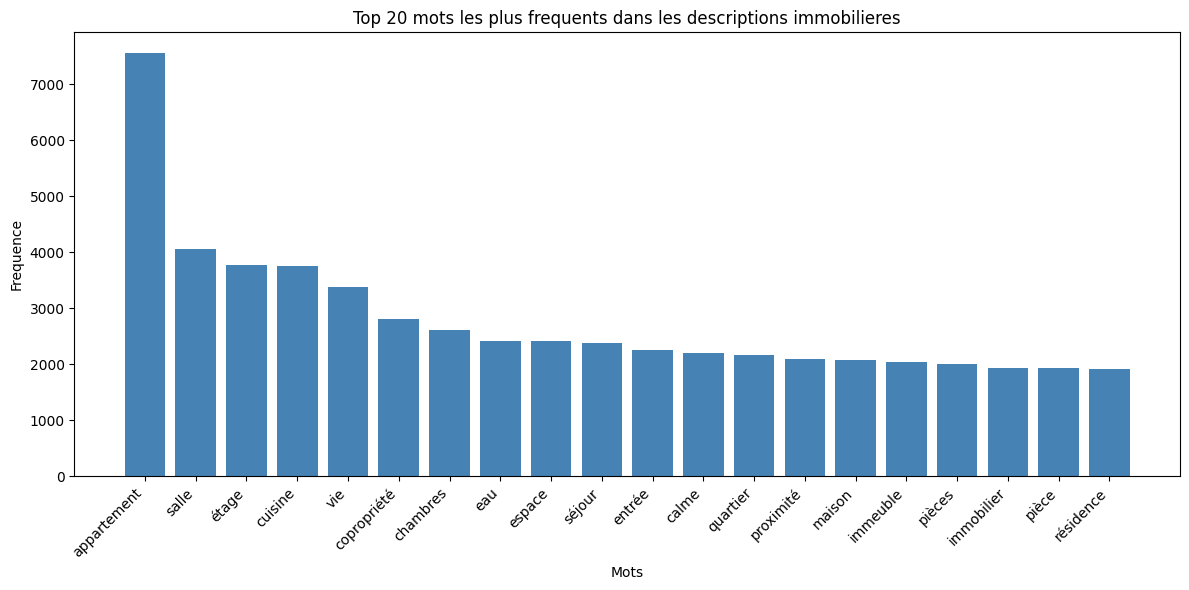

Graphique sauvegarde


In [79]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top50_pd['mot'][:20], top50_pd['count'][:20], color='steelblue')
ax.set_xlabel('Mots')
ax.set_ylabel('Frequence')
ax.set_title('Top 20 mots les plus frequents dans les descriptions immobilieres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/barplot_nlp.png', dpi=100)
plt.show()
print('Graphique sauvegarde')

## Etape 7 — Interpretation des resultats NLP

Les mots les plus frequents revelent :
- **Attributs positifs** : calme, lumineux, vue, exclusivit
- **Equipements** : terrasse, balcon, parking, garage, cave
- **Localisation** : quartier, proche, commerces
- **Type de bien** : appartement, maison, studio, duplex

Ces 50 mots serviront de **features binaires** (presence/absence) pour le pipeline ML.

In [80]:
# Récupérer la liste des mots pour le notebook ML
TOP50_FEATURES = []
for row in top50_df.collect():
    TOP50_FEATURES.append(row['mot'])

print('Top 50 mots (à réutiliser dans le notebook 04) :')
print(TOP50_FEATURES)
spark.stop()

Top 50 mots (à réutiliser dans le notebook 04) :
['appartement', 'salle', 'étage', 'cuisine', 'vie', 'copropriété', 'chambres', 'eau', 'espace', 'séjour', 'entrée', 'calme', 'quartier', 'proximité', 'maison', 'immeuble', 'pièces', 'immobilier', 'pièce', 'résidence', 'chambre', 'lumineux', 'commerces', 'terrasse', 'rue', 'ascenseur', 'équipée', 'exposé', 'place', 'jardin', 'balcon', 'vue', 'transports', 'cave', 'sud', 'entièrement', 'idéal', 'agréable', 'parking', 'risques', 'coeur', 'saint', 'immédiate', 'georisques', 'gouv', 'recherché', 'cadre', 'énergie', 'double', 'vis']


## Interprétation des résultats

Les 50 mots les plus fréquents révèlent plusieurs catégories de features exploitables pour le ML :

**Attributs qualitatifs du bien** : `calme`, `lumineux`, `agréable`, `idéal`, `recherché`, `entièrement`, `double`, `vis` (probablement "sans vis-à-vis") — ces adjectifs portent un signal fort sur la désirabilité.

**Équipements et espaces** : `terrasse`, `balcon`, `jardin`, `parking`, `cave`, `ascenseur`, `cuisine`, `salle`, `séjour`, `entrée`, `espace`, `place` — indicateurs concrets de la valeur ajoutée d'un bien.

**Exposition et luminosité** : `sud`, `exposé`, `vue` — l'orientation et la vue sont des critères de prix importants.

**Localisation et proximité** : `quartier`, `proximité`, `commerces`, `transports`, `rue`, `coeur`, `immédiate`, `saint` — signal de centralité et d'accessibilité.

**Structure du bien** : `pièces`, `pièce`, `chambres`, `chambre`, `étage`, `appartement`, `maison`, `immeuble`, `studio`, `résidence`, `copropriété` — termes descriptifs qui recoupent partiellement nos features structurées.

**Mentions légales (bruit)** : `risques`, `georisques`, `gouv`, `énergie` — issus des mentions DPE/risques obligatoires, peu utiles mais présents uniformément.

Ces mots servent de **features binaires** (présence/absence) dans le notebook 04, complémentaires aux variables numériques (surface, pièces) et catégorielles (ville, type).